# Bayesian Neural Networks from Bayes' Rule to Surrogates

**Learning objectives**
- Keep a concrete physical question in view: how uncertain are the damping ratio and natural frequency of a noisy oscillator?
- Use basic probability distributions to express priors and likelihoods, then connect them through Bayes' theorem.
- Solve a closed-form Bayesian linear regression before turning to approximations.
- Treat variational inference as optimization and reuse that idea inside Bayes-by-Backprop.
- Build a Bayesian neural network surrogate and contrast it with Pyro/ensemble/dropout approximations.

**Notebook**: [![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/kks32-courses/sciml/blob/main/docs/09-bayes-cnf/09a-bnn.ipynb)
**Slides**: [![PDF](https://img.shields.io/badge/Slides-PDF-red)](https://github.com/kks32-courses/sciml/blob/main/docs/09-bayes-cnf/09-bnn-slides.pdf)

## How to use this notebook
- Requires PyTorch, matplotlib, and `torchdiffeq` for the oscillator example.
- The distribution primer uses seaborn and SciPy; install them if missing.
- The Pyro section is optional. Run `pip install pyro-ppl` first if you want to execute it.


In [22]:
!pip3 install seaborn


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip


In [23]:
import math
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.distributions import Normal, Uniform
from torchdiffeq import odeint

plt.style.use('seaborn-v0_8-colorblind')
plt.rcParams['figure.figsize'] = (8, 4)
plt.rcParams['axes.grid'] = True

def choose_device():
    if torch.cuda.is_available():
        return torch.device('cuda')
    if hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
        return torch.device('mps')
    return torch.device('cpu')

torch.set_default_dtype(torch.float32)
device = choose_device()
torch.manual_seed(0)
np.random.seed(0)
print(f'Using device: {device}')


Using device: mps


## A concrete question: a noisy damped oscillator
Instead of abstract symbols, start with something we can picture. A lightly damped mass-spring system is measured by noisy sensors. We know the governing ODE, but we do not know the damping ratio $\zeta$ or natural frequency $\omega_n$ exactly, and we need credible predictions beyond the measured time window. The same example will anchor every section below.


In [24]:
def damped_oscillator(t, state, zeta, omega_n):
    # Time derivative for the 2-state oscillator system.
    x = state[..., 0]
    v = state[..., 1]
    dxdt = v
    dvdt = -2.0 * zeta * omega_n * v - omega_n**2 * x
    return torch.stack((dxdt, dvdt), dim=-1)


def solve_oscillator(theta, t_eval, x0=1.0, v0=0.0):
    # Run on CPU to avoid MPS float64 compatibility issues with torchdiffeq
    compute_device = torch.device('cpu')
    theta_cpu = theta.to(compute_device)
    t_eval_cpu = t_eval.to(compute_device)

    zeta, omega_n = theta_cpu
    y0 = torch.tensor([x0, v0], dtype=torch.float32, device=compute_device)
    sol = odeint(lambda t, y: damped_oscillator(t, y, zeta, omega_n), y0, t_eval_cpu)
    return sol[:, 0].to(t_eval.device)


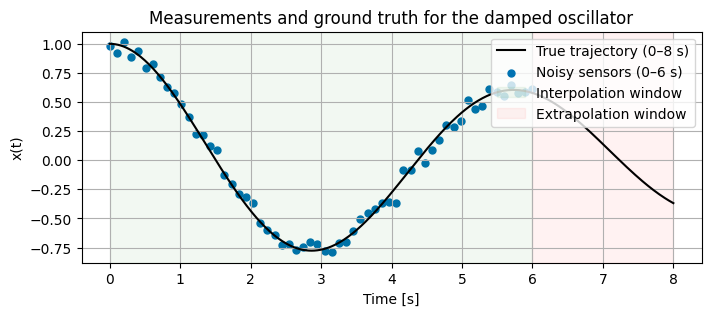

In [25]:
theta_true = torch.tensor([0.08, 1.1], device=device)
t_all = torch.linspace(0.0, 8.0, steps=400, device=device)
x_all = solve_oscillator(theta_true, t_all)

# Training (interpolation) window: 0 to 6 seconds
train_mask = t_all <= 6.0
t_train = torch.linspace(0.0, 6.0, steps=60, device=device)
x_train_clean = solve_oscillator(theta_true, t_train)
noise_std = 0.05
x_train = x_train_clean + noise_std * torch.randn_like(x_train_clean)

with torch.no_grad():
    t_extrap = torch.linspace(6.0, 8.0, steps=80, device=device)
    x_extrap_clean = solve_oscillator(theta_true, t_extrap)

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(t_all.cpu(), x_all.cpu(), label='True trajectory (0–8 s)', color='black')
ax.scatter(t_train.cpu(), x_train.cpu(), s=25, color='C0', label='Noisy sensors (0–6 s)')
ax.axvspan(0, 6, color='green', alpha=0.05, label='Interpolation window')
ax.axvspan(6, 8, color='red', alpha=0.05, label='Extrapolation window')
ax.set_xlabel('Time [s]')
ax.set_ylabel('x(t)')
ax.set_title('Measurements and ground truth for the damped oscillator')
ax.legend(loc='upper right')
plt.show()


## Probability distributions we lean on
Bayesian models are built from distributions. Three families cover most of what we need:
- **Normal:** models measurement noise and many priors on weights.
- **Gamma / inverse-gamma:** positive-only scales and precisions.
- **Uniform:** weakly informative windows, useful when we only know plausible bounds.

The small visual tour below mirrors the `11a-distribution` notebook.


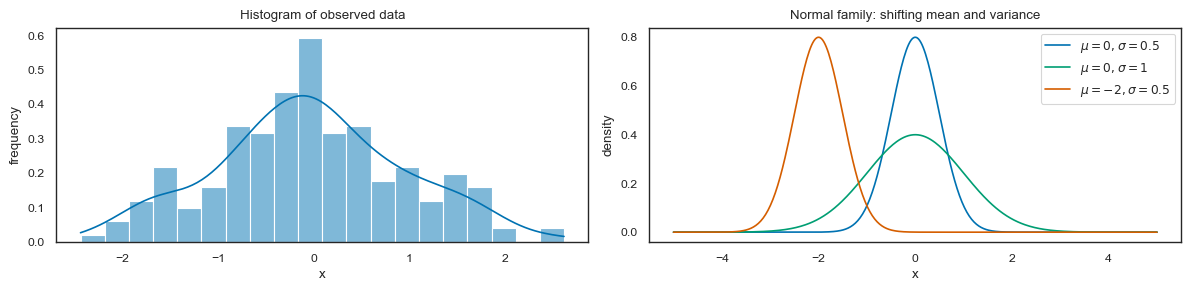

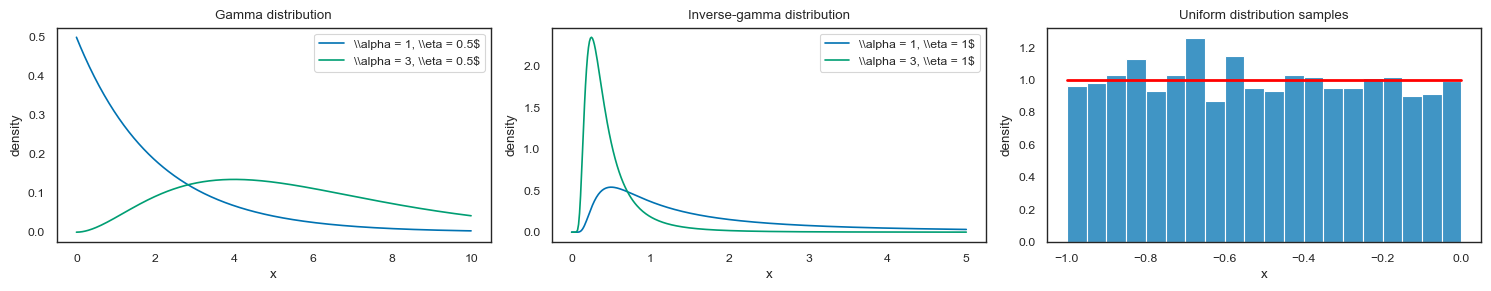

In [27]:
import seaborn as sns
from math import sqrt
from scipy.stats import norm, gamma, invgamma

sns.set_style('white')
sns.set_context('paper')


def plot_distributions(x_data, pdf_data, title='', ax=None):
    if ax is None:
        ax = plt.gca()
    for label, pdf in pdf_data.items():
        ax.plot(x_data, pdf, label=label)
    ax.legend()
    ax.set_title(title)
    ax.set_xlabel('x')
    ax.set_ylabel('density')


# Normal distribution: samples plus density variations
fig, axes = plt.subplots(1, 2, figsize=(12, 3))
data = np.random.randn(200)
sns.histplot(data, kde=True, bins=20, ax=axes[0], stat='density')
axes[0].set(title='Histogram of observed data', xlabel='x', ylabel='frequency')

x = np.linspace(-5, 5, 400)
plot_distributions(
    x,
    {
        '$\\mu = 0, \\sigma = 0.5$': norm.pdf(x, 0, 0.5),
        '$\\mu = 0, \\sigma = 1$': norm.pdf(x, 0, 1),
        '$\\mu = -2, \\sigma = 0.5$': norm.pdf(x, -2, 0.5),
    },
    title='Normal family: shifting mean and variance',
    ax=axes[1],
)
plt.tight_layout()
plt.show()

# Gamma, inverse-gamma, and uniform
fig, axes = plt.subplots(1, 3, figsize=(15, 3))

x = np.linspace(0, 10, 400)
plot_distributions(
    x,
    {
        r'\\alpha = 1, \\eta = 0.5$': gamma.pdf(x, a=1, scale=2),
        r'\\alpha = 3, \\eta = 0.5$': gamma.pdf(x, a=3, scale=2),
    },
    title='Gamma distribution',
    ax=axes[0],
)

x = np.linspace(0, 5, 400)
plot_distributions(
    x,
    {
        r'\\alpha = 1, \\eta = 1$': invgamma.pdf(x, a=1, scale=1),
        r'\\alpha = 3, \\eta = 1$': invgamma.pdf(x, a=3, scale=1),
    },
    title='Inverse-gamma distribution',
    ax=axes[1],
)

s_uniform = np.random.uniform(-1, 0, 2000)
sns.histplot(s_uniform, kde=False, ax=axes[2], bins=20, stat='density')
bins = np.linspace(-1, 0, 20)
axes[2].plot(bins, np.ones_like(bins), linewidth=2, color='r')
axes[2].set(title='Uniform distribution samples', xlabel='x', ylabel='density')

plt.tight_layout()
plt.show()


## Bayes' theorem on the oscillator parameters
Bayes' rule links what we believe before seeing data (prior) with what the data say (likelihood). For the oscillator we choose broad uniform priors over damping $\zeta$ and natural frequency $\omega_n$, then evaluate the posterior on a small grid. This is only feasible because the parameter space is two dimensional, but it makes the ingredients tangible.


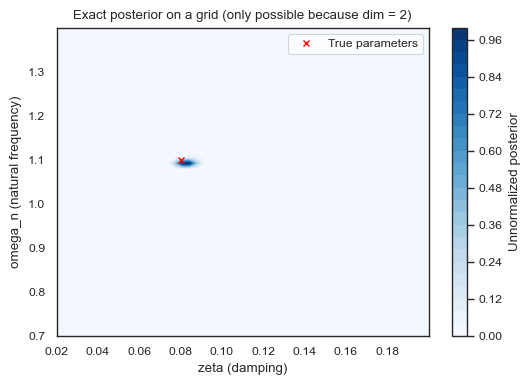

In [28]:
prior_zeta = Uniform(0.0, 0.25)
prior_omega = Uniform(0.6, 1.6)


def log_prior_oscillator(theta):
    zeta = theta[..., 0]
    omega = theta[..., 1]
    return prior_zeta.log_prob(zeta) + prior_omega.log_prob(omega)


def log_likelihood_oscillator(theta, y_obs, noise_std, t_eval):
    if theta.ndim == 1:
        theta = theta.unsqueeze(0)
    log_lik = []
    for th in theta:
        pred = solve_oscillator(th, t_eval)
        log_lik.append(Normal(pred, noise_std).log_prob(y_obs).sum())
    return torch.stack(log_lik)


zeta_vals = torch.linspace(0.02, 0.2, steps=60, device=device)
omega_vals = torch.linspace(0.7, 1.4, steps=60, device=device)
posterior_grid = torch.zeros(len(zeta_vals), len(omega_vals))

for i, zeta in enumerate(zeta_vals):
    for j, omega in enumerate(omega_vals):
        theta = torch.tensor([zeta, omega], device=device)
        log_post = log_prior_oscillator(theta) + log_likelihood_oscillator(theta, x_train, noise_std, t_train)
        posterior_grid[i, j] = log_post

posterior_grid = torch.exp(posterior_grid - posterior_grid.max())
ZETA, OMEGA = torch.meshgrid(zeta_vals.cpu(), omega_vals.cpu(), indexing='ij')

fig, ax = plt.subplots(figsize=(6, 4))
cs = ax.contourf(ZETA, OMEGA, posterior_grid.cpu().numpy(), levels=25, cmap='Blues')
ax.plot(theta_true[0].cpu(), theta_true[1].cpu(), 'rx', label='True parameters')
ax.set_xlabel('zeta (damping)')
ax.set_ylabel('omega_n (natural frequency)')
ax.set_title('Exact posterior on a grid (only possible because dim = 2)')
ax.legend()
fig.colorbar(cs, ax=ax, label='Unnormalized posterior')
plt.show()


## Bayesian linear regression: the analytical stepping stone
Before touching neural networks, do Bayes where the algebra is exact. Linear basis function models assume
$$y(\mathbf{x}, \mathbf{w}) = w_0 + \sum_{j=1}^{M-1} w_j \phi_j(\mathbf{x}) = \mathbf{w}^T \boldsymbol\phi(\mathbf{x})$$
with Gaussian noise of precision $\beta$ and a Gaussian prior $\mathcal{N}(\mathbf{0}, \alpha^{-1} \mathbf{I})$ on $\mathbf{w}$. Conjugacy gives a Gaussian posterior with mean $\mathbf{m}_N$ and covariance $\mathbf{S}_N$ and a predictive distribution that combines data noise and weight uncertainty.

In [29]:
import numpy as np
from scipy import stats


def posterior(Phi, t, alpha, beta, return_inverse=False):
    '''Mean and covariance of the Gaussian posterior over weights.'''
    S_N_inv = alpha * np.eye(Phi.shape[1]) + beta * Phi.T.dot(Phi)
    S_N = np.linalg.inv(S_N_inv)
    m_N = beta * S_N.dot(Phi.T).dot(t)
    if return_inverse:
        return m_N, S_N, S_N_inv
    return m_N, S_N


def posterior_predictive(Phi_test, m_N, S_N, beta):
    '''Mean and variances of the posterior predictive distribution.'''
    y = Phi_test.dot(m_N)
    y_var = 1 / beta + np.sum(Phi_test.dot(S_N) * Phi_test, axis=1)
    return y, y_var


def identity_basis_function(x):
    return x


def gaussian_basis_function(x, mu, sigma=0.1):
    return np.exp(-0.5 * (x - mu) ** 2 / sigma ** 2)


def polynomial_basis_function(x, power):
    return x ** power


def expand(x, bf, bf_args=None):
    if bf_args is None:
        return np.concatenate([np.ones(x.shape), bf(x)], axis=1)
    return np.concatenate([np.ones(x.shape)] + [bf(x, bf_arg) for bf_arg in bf_args], axis=1)


def f(X, noise_variance):
    '''Linear function plus noise for straight-line regression.'''
    w0, w1 = -0.3, 0.5
    return w0 + w1 * X + np.random.normal(scale=np.sqrt(noise_variance), size=X.shape)


def g(X, noise_variance):
    '''Sinusoidal function plus noise for nonlinear examples.'''
    return 0.5 + np.sin(2 * np.pi * X) + np.random.normal(scale=np.sqrt(noise_variance), size=X.shape)


/var/folders/w8/xz590jyd7r36zmxcspgzj3z40000gn/T/ipykernel_98107/2996871843.py:53: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


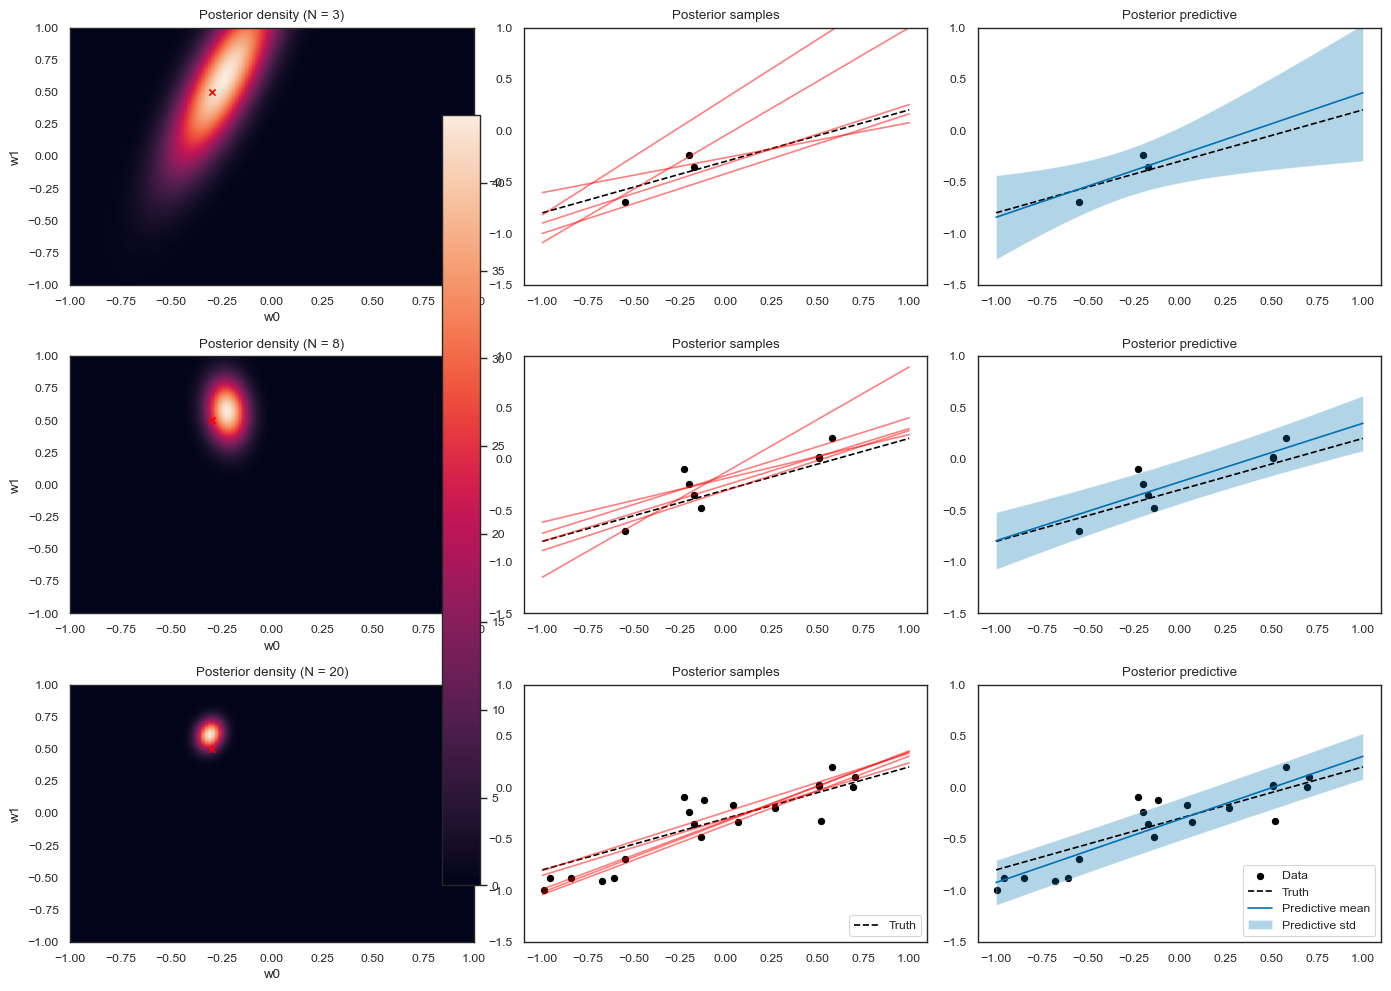

In [30]:
# Straight-line regression with growing data
N_list = [3, 8, 20]
beta = 25.0
alpha = 2.0

X = np.random.rand(N_list[-1], 1) * 2 - 1
t = f(X, noise_variance=1 / beta)
X_test = np.linspace(-1, 1, 100).reshape(-1, 1)
y_true = f(X_test, noise_variance=0)
Phi_test = expand(X_test, identity_basis_function)

fig, axes = plt.subplots(len(N_list), 3, figsize=(14, 10))
plt.subplots_adjust(hspace=0.4)

for i, N in enumerate(N_list):
    X_N = X[:N]
    t_N = t[:N]
    Phi_N = expand(X_N, identity_basis_function)

    m_N, S_N = posterior(Phi_N, t_N, alpha, beta)
    y, y_var = posterior_predictive(Phi_test, m_N, S_N, beta)
    w_samples = np.random.multivariate_normal(m_N.ravel(), S_N, 5).T
    y_samples = Phi_test.dot(w_samples)

    ax_post = axes[i, 0]
    grid_x = grid_y = np.linspace(-1, 1, 120)
    grid_flat = np.dstack(np.meshgrid(grid_x, grid_y)).reshape(-1, 2)
    densities = stats.multivariate_normal.pdf(grid_flat, mean=m_N.ravel(), cov=S_N).reshape(len(grid_x), len(grid_y))
    im = ax_post.imshow(densities, origin='lower', extent=(-1, 1, -1, 1), aspect='auto')
    ax_post.scatter(-0.3, 0.5, marker='x', c='r', s=20, label='Truth')
    ax_post.set_title(f'Posterior density (N = {N})')
    ax_post.set_xlabel('w0')
    ax_post.set_ylabel('w1')

    ax_samples = axes[i, 1]
    ax_samples.scatter(X_N, t_N, marker='o', c='k', s=20)
    ax_samples.plot(X_test, y_true, 'k--', label='Truth')
    ax_samples.plot(X_test, y_samples, 'r-', alpha=0.5)
    ax_samples.set_ylim(-1.5, 1.0)
    ax_samples.set_title('Posterior samples')

    ax_pred = axes[i, 2]
    ax_pred.scatter(X_N, t_N, marker='o', c='k', s=20, label='Data')
    ax_pred.plot(X_test, y_true, 'k--', label='Truth')
    ax_pred.plot(X_test, y, label='Predictive mean')
    ax_pred.fill_between(X_test.ravel(), y.ravel() + np.sqrt(y_var), y.ravel() - np.sqrt(y_var), alpha=0.3, label='Predictive std')
    ax_pred.set_ylim(-1.5, 1.0)
    ax_pred.set_title('Posterior predictive')

axes[-1, 1].legend(loc='lower right')
axes[-1, 2].legend(loc='lower right')
fig.colorbar(im, ax=axes[:, 0].tolist())
plt.tight_layout()
plt.show()


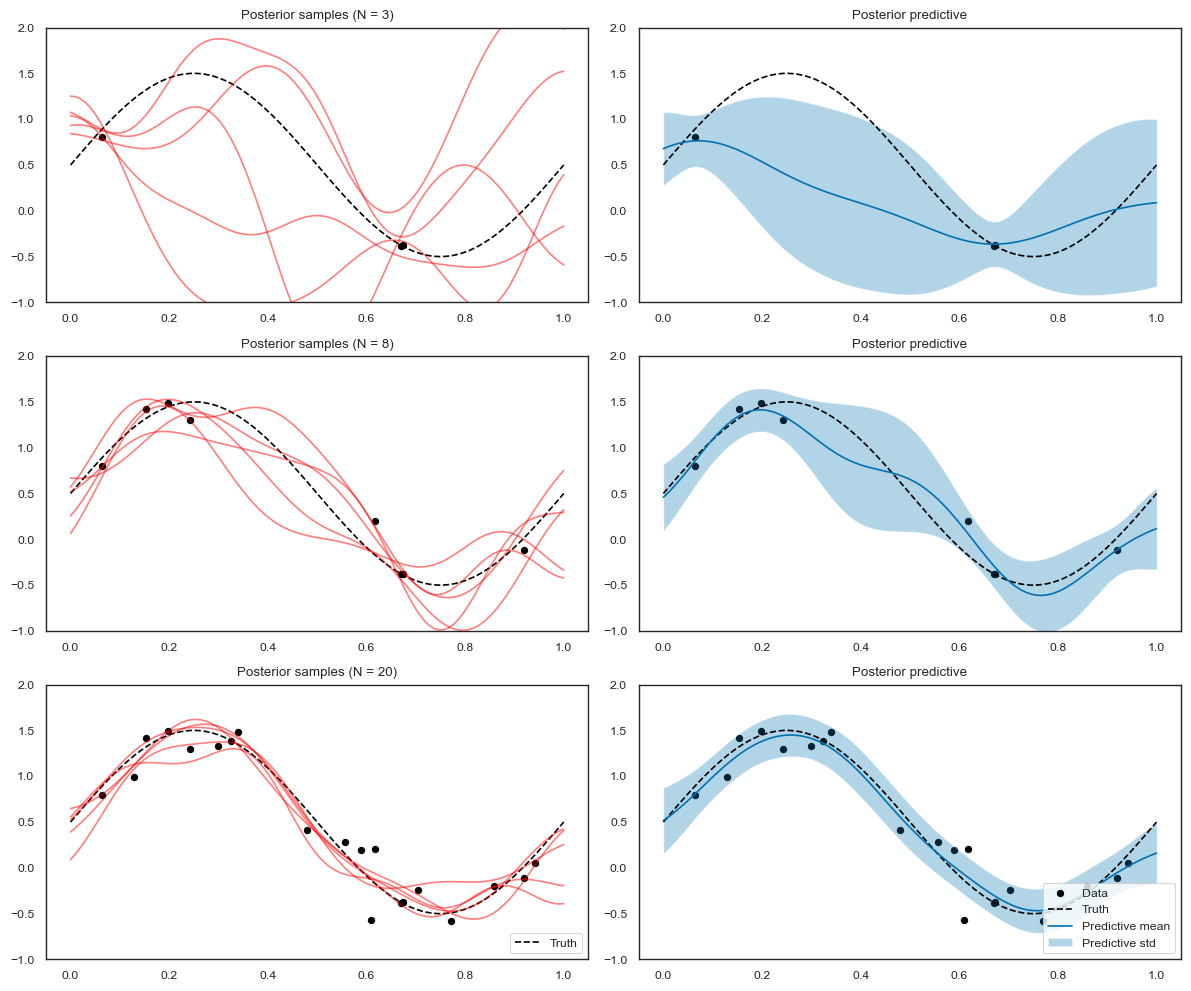

In [31]:
# Nonlinear regression with Gaussian basis functions
N_list = [3, 8, 20]
beta = 25.0
alpha = 2.0

X = np.random.rand(N_list[-1], 1)
t = g(X, noise_variance=1 / beta)
X_test = np.linspace(0, 1, 100).reshape(-1, 1)
y_true = g(X_test, noise_variance=0)
Phi_test = expand(X_test, bf=gaussian_basis_function, bf_args=np.linspace(0, 1, 9))

fig, axes = plt.subplots(len(N_list), 2, figsize=(12, 10))
plt.subplots_adjust(hspace=0.4)

for i, N in enumerate(N_list):
    X_N = X[:N]
    t_N = t[:N]
    Phi_N = expand(X_N, bf=gaussian_basis_function, bf_args=np.linspace(0, 1, 9))

    m_N, S_N = posterior(Phi_N, t_N, alpha, beta)
    y, y_var = posterior_predictive(Phi_test, m_N, S_N, beta)
    w_samples = np.random.multivariate_normal(m_N.ravel(), S_N, 5).T
    y_samples = Phi_test.dot(w_samples)

    ax_samples = axes[i, 0]
    ax_samples.scatter(X_N, t_N, marker='o', c='k', s=20)
    ax_samples.plot(X_test, y_true, 'k--', label='Truth')
    ax_samples.plot(X_test, y_samples, 'r-', alpha=0.5)
    ax_samples.set_ylim(-1.0, 2.0)
    ax_samples.set_title(f'Posterior samples (N = {N})')

    ax_pred = axes[i, 1]
    ax_pred.scatter(X_N, t_N, marker='o', c='k', s=20, label='Data')
    ax_pred.plot(X_test, y_true, 'k--', label='Truth')
    ax_pred.plot(X_test, y, label='Predictive mean')
    ax_pred.fill_between(X_test.ravel(), y.ravel() + np.sqrt(y_var), y.ravel() - np.sqrt(y_var), alpha=0.3, label='Predictive std')
    ax_pred.set_ylim(-1.0, 2.0)
    ax_pred.set_title('Posterior predictive')

axes[-1, 0].legend(loc='lower right')
axes[-1, 1].legend(loc='lower right')
plt.tight_layout()
plt.show()


Posterior densities sharpen as more data arrive; predictive bands shrink where we have observations and widen elsewhere. Basis functions act like hand-crafted features that let a linear model fit a sinusoid without overfitting.

## Evidence and model complexity
The marginal likelihood (evidence) rewards models that fit well *and* are not overly complex. For polynomial bases of increasing degree, the log evidence typically peaks at a moderate degree because higher degrees add parameters that the prior pushes toward zero.


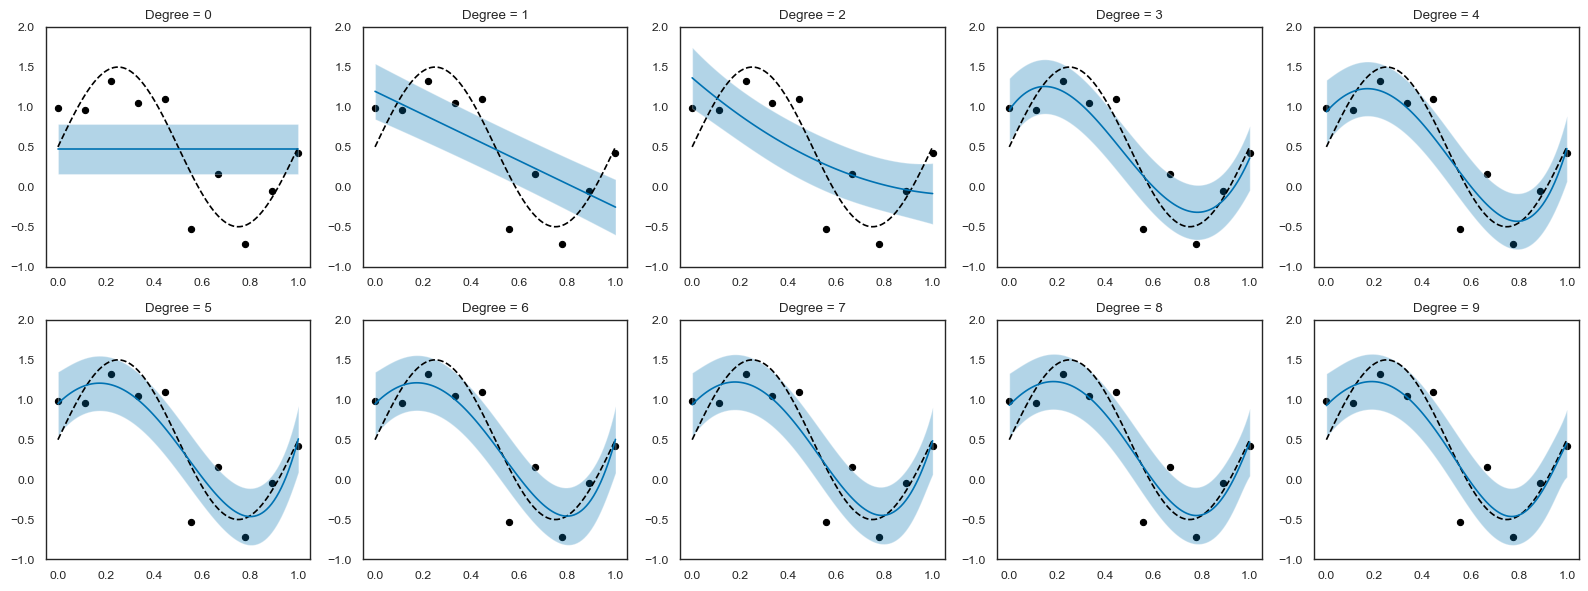

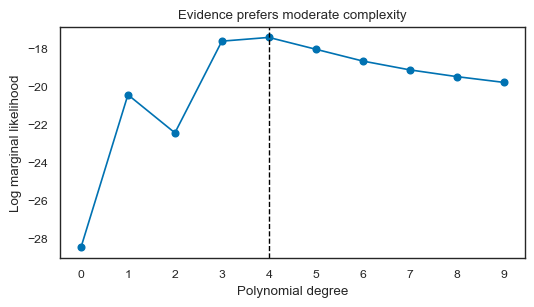

In [32]:
def log_marginal_likelihood(Phi, t, alpha, beta):
    '''Log evidence for a linear model with design matrix Phi.'''
    N, M = Phi.shape
    m_N, _, S_N_inv = posterior(Phi, t, alpha, beta, return_inverse=True)
    E_D = beta * np.sum((t - Phi.dot(m_N)) ** 2)
    E_W = alpha * np.sum(m_N ** 2)
    score = M * np.log(alpha) + N * np.log(beta) - E_D - E_W - np.log(np.linalg.det(S_N_inv)) - N * np.log(2 * np.pi)
    return 0.5 * score


np.random.seed(1)
N = 10
beta = 1 / (0.3 ** 2)
alpha = 0.005
degree = 9
degrees = range(degree + 1)

X = np.linspace(0, 1, N).reshape(-1, 1)
t = g(X, noise_variance=1 / beta)
Phi = expand(X, bf=polynomial_basis_function, bf_args=degrees[1:])
Phi_test = expand(np.linspace(0, 1, 100).reshape(-1, 1), bf=polynomial_basis_function, bf_args=degrees[1:])
y_true = g(np.linspace(0, 1, 100).reshape(-1, 1), noise_variance=0)

mlls = []
fig, axes = plt.subplots(2, 5, figsize=(16, 6))
for d in degrees:
    up = d + 1
    m_N, S_N = posterior(Phi[:, :up], t, alpha, beta)
    y, y_var = posterior_predictive(Phi_test[:, :up], m_N, S_N, beta)
    mll = log_marginal_likelihood(Phi[:, :up], t, alpha=alpha, beta=beta)
    mlls.append(mll)

    ax = axes.ravel()[d]
    ax.scatter(X, t, marker='o', c='k', s=20)
    ax.plot(np.linspace(0, 1, 100), y_true, 'k--', label='Truth')
    ax.plot(np.linspace(0, 1, 100), y, label='Predictive mean')
    ax.fill_between(np.linspace(0, 1, 100), y.ravel() + np.sqrt(y_var), y.ravel() - np.sqrt(y_var), alpha=0.3)
    ax.set_title(f'Degree = {d}')
    ax.set_ylim(-1.0, 2.0)

fig.tight_layout()
plt.show()

plt.figure(figsize=(6, 3))
plt.plot(degrees, mlls, marker='o')
plt.axvline(x=int(np.argmax(mlls)), ls='--', c='k', lw=1)
plt.xticks(range(0, 10))
plt.xlabel('Polynomial degree')
plt.ylabel('Log marginal likelihood')
plt.title('Evidence prefers moderate complexity')
plt.show()


## Variational inference as optimization
Exact Bayes works for linear-Gaussian models; neural nets need approximations. Variational inference (VI) replaces the true posterior with a tractable family $q_\phi(\theta)$ and fits $\phi$ by maximizing the evidence lower bound (ELBO). The scalar example below mirrors the warm-up in this notebook: we approximate a bimodal posterior with a single Gaussian.


<>:60: SyntaxWarning: invalid escape sequence '\p'
<>:60: SyntaxWarning: invalid escape sequence '\p'
/var/folders/w8/xz590jyd7r36zmxcspgzj3z40000gn/T/ipykernel_98107/2562554883.py:60: SyntaxWarning: invalid escape sequence '\p'
  axes[0].plot(theta_grid, q_density, label='Variational $q_\phi$', linestyle='--')


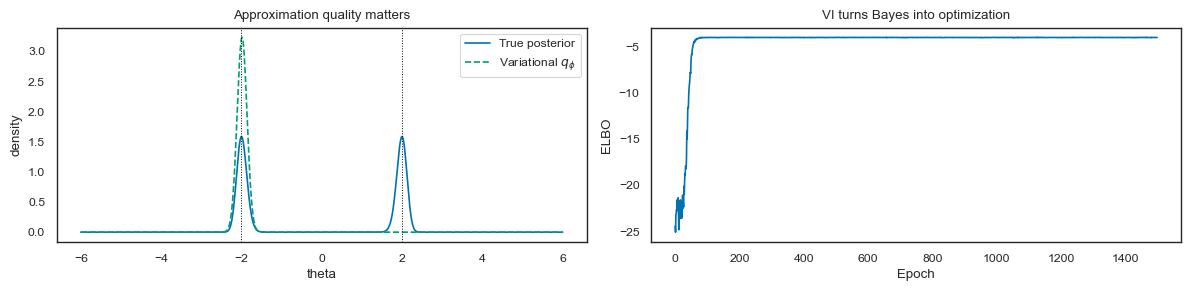

In [33]:
scalar_prior = Normal(0.0, 5.0)
scalar_noise = 0.5
y_obs_scalar = torch.tensor(4.0)

def log_prior_scalar(theta):
    return scalar_prior.log_prob(theta)

def log_likelihood_scalar(theta, y_obs, noise_std=scalar_noise):
    y_pred = theta ** 2
    return Normal(y_pred, noise_std).log_prob(y_obs)

def log_posterior_scalar(theta, y_obs):
    return log_likelihood_scalar(theta, y_obs) + log_prior_scalar(theta)


theta_grid = torch.linspace(-6.0, 6.0, steps=2000)
log_post_vals = log_posterior_scalar(theta_grid, y_obs_scalar)
posterior_density = torch.exp(log_post_vals - log_post_vals.max())
posterior_density /= posterior_density.sum() * (theta_grid[1] - theta_grid[0])


class VariationalGaussian(nn.Module):
    def __init__(self, init_mu=0.0, init_log_std=0.0):
        super().__init__()
        self.mu = nn.Parameter(torch.tensor(init_mu, dtype=torch.float32))
        self.log_std = nn.Parameter(torch.tensor(init_log_std, dtype=torch.float32))

    def rsample(self, n_samples):
        eps = torch.randn(n_samples)
        return self.mu + torch.exp(self.log_std) * eps

    def log_prob(self, theta):
        std = torch.exp(self.log_std)
        return Normal(self.mu, std).log_prob(theta)


gaussian_vi = VariationalGaussian()
optimizer = optim.Adam(gaussian_vi.parameters(), lr=0.05)
elbo_history = []
n_epochs = 1500
n_mc = 256

for epoch in range(1, n_epochs + 1):
    optimizer.zero_grad()
    theta_samples = gaussian_vi.rsample(n_mc)
    log_q = gaussian_vi.log_prob(theta_samples)
    log_prior_vals = log_prior_scalar(theta_samples)
    log_like_vals = log_likelihood_scalar(theta_samples, y_obs_scalar)
    elbo = (log_like_vals + log_prior_vals - log_q).mean()
    (-elbo).backward()
    optimizer.step()
    elbo_history.append(elbo.item())

with torch.no_grad():
    q_density = torch.exp(gaussian_vi.log_prob(theta_grid))
    q_density /= q_density.sum() * (theta_grid[1] - theta_grid[0])

fig, axes = plt.subplots(1, 2, figsize=(12, 3))
axes[0].plot(theta_grid, posterior_density, label='True posterior')
axes[0].plot(theta_grid, q_density, label='Variational $q_\phi$', linestyle='--')
axes[0].axvline(2.0, color='k', linestyle=':', linewidth=0.7)
axes[0].axvline(-2.0, color='k', linestyle=':', linewidth=0.7)
axes[0].set_xlabel('theta')
axes[0].set_ylabel('density')
axes[0].set_title('Approximation quality matters')
axes[0].legend()

axes[1].plot(elbo_history)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('ELBO')
axes[1].set_title('VI turns Bayes into optimization')
plt.tight_layout()
plt.show()


The single Gaussian cannot capture both modes, foreshadowing what happens when we approximate thousands of neural-network weights with factorized Gaussians. We still gain a fast-to-optimize objective that balances data fit and prior.

## Bayesian neural network surrogate for the oscillator
We now scale the scalar VI idea to a neural network: each weight has a Gaussian variational posterior. The loss is a Monte Carlo estimate of the negative ELBO (Bayes-by-Backprop).


In [34]:
# Normalize time to [-1, 1] based on the interpolation window
min_t, max_t = t_train.min(), t_train.max()

def normalize_time(t):
    return 2 * (t - min_t) / (max_t - min_t) - 1


t_train_norm = normalize_time(t_train).unsqueeze(-1)
x_train_targets = x_train.unsqueeze(-1)

# Dense evaluation grid (0–8 seconds)
t_eval = torch.linspace(0.0, 8.0, steps=300, device=device).unsqueeze(-1)
t_eval_norm = normalize_time(t_eval)
true_eval = solve_oscillator(theta_true, t_eval.squeeze(-1)).unsqueeze(-1)


In [35]:
class BayesianLinear(nn.Module):
    def __init__(self, in_features, out_features, prior_std=1.0):
        super().__init__()
        self.weight_mu = nn.Parameter(torch.randn(out_features, in_features) * 0.1)
        self.weight_rho = nn.Parameter(torch.full((out_features, in_features), -3.0))
        self.bias_mu = nn.Parameter(torch.zeros(out_features))
        self.bias_rho = nn.Parameter(torch.full((out_features,), -3.0))
        self.prior = Normal(0.0, prior_std)

    def _sample(self):
        weight_sigma = torch.log1p(torch.exp(self.weight_rho))
        bias_sigma = torch.log1p(torch.exp(self.bias_rho))
        weight = self.weight_mu + weight_sigma * torch.randn_like(weight_sigma)
        bias = self.bias_mu + bias_sigma * torch.randn_like(bias_sigma)
        log_q = Normal(self.weight_mu, weight_sigma).log_prob(weight).sum()
        log_q += Normal(self.bias_mu, bias_sigma).log_prob(bias).sum()
        log_p = self.prior.log_prob(weight).sum() + self.prior.log_prob(bias).sum()
        return weight, bias, log_q, log_p

    def forward(self, x, sample=True):
        if self.training or sample:
            weight, bias, log_q, log_p = self._sample()
        else:
            weight, bias = self.weight_mu, self.bias_mu
            log_q = log_p = torch.tensor(0.0, device=x.device)
        return F.linear(x, weight, bias), log_q, log_p


class BayesianMLP(nn.Module):
    def __init__(self, hidden_dim=64, prior_std=1.0):
        super().__init__()
        self.layer1 = BayesianLinear(1, hidden_dim, prior_std)
        self.layer2 = BayesianLinear(hidden_dim, hidden_dim, prior_std)
        self.layer3 = BayesianLinear(hidden_dim, 1, prior_std)

    def forward(self, x, sample=True):
        log_q = 0.0
        log_p = 0.0
        out, lq, lp = self.layer1(x, sample)
        log_q += lq
        log_p += lp
        out = torch.tanh(out)
        out, lq, lp = self.layer2(out, sample)
        log_q += lq
        log_p += lp
        out = torch.tanh(out)
        out, lq, lp = self.layer3(out, sample)
        log_q += lq
        log_p += lp
        return out, log_q, log_p

    def predictive_samples(self, x, n_samples=200):
        self.eval()
        preds = []
        with torch.no_grad():
            for _ in range(n_samples):
                y_hat, _, _ = self.forward(x, sample=True)
                preds.append(y_hat)
        return torch.stack(preds)


def bayes_by_backprop_step(model, x, y, noise_std, n_samples=4):
    log_q = 0.0
    log_p = 0.0
    log_likelihood = 0.0
    for _ in range(n_samples):
        preds, sample_log_q, sample_log_p = model(x)
        log_q += sample_log_q
        log_p += sample_log_p
        log_likelihood += Normal(preds, noise_std).log_prob(y).sum()
    log_q /= n_samples
    log_p /= n_samples
    log_likelihood /= n_samples
    return log_q - log_p - log_likelihood


Epoch 500, negative ELBO: 5022.455
Epoch 1000, negative ELBO: 2289.078
Epoch 1500, negative ELBO: 1568.338
Epoch 2000, negative ELBO: 970.782
Epoch 2500, negative ELBO: 906.166
Epoch 3000, negative ELBO: 826.065
Epoch 3500, negative ELBO: 753.771


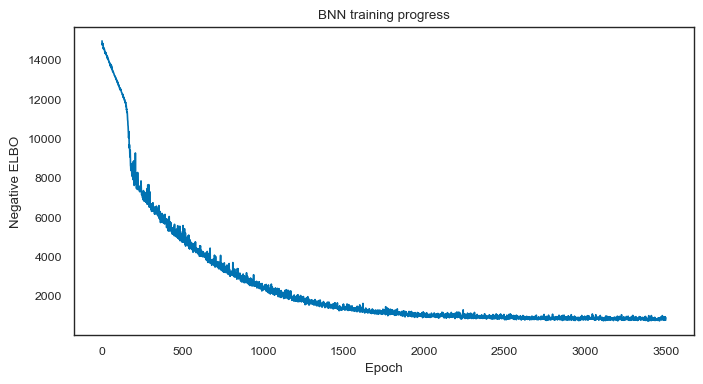

In [36]:
model_bnn = BayesianMLP(hidden_dim=64, prior_std=1.0).to(device)
optimizer = optim.Adam(model_bnn.parameters(), lr=5e-3)
loss_history = []
n_epochs = 3500

for epoch in range(1, n_epochs + 1):
    optimizer.zero_grad()
    loss = bayes_by_backprop_step(model_bnn, t_train_norm, x_train_targets, noise_std, n_samples=6)
    loss.backward()
    optimizer.step()
    loss_history.append(loss.item())
    if epoch % 500 == 0:
        print(f'Epoch {epoch}, negative ELBO: {loss.item():.3f}')

fig, ax = plt.subplots()
ax.plot(loss_history)
ax.set_xlabel('Epoch')
ax.set_ylabel('Negative ELBO')
ax.set_title('BNN training progress')
plt.show()


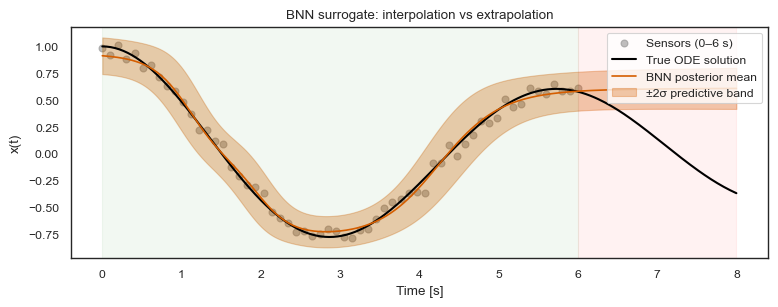

In [37]:
with torch.no_grad():
    preds = model_bnn.predictive_samples(t_eval_norm, n_samples=300)
mean_pred = preds.mean(dim=0)
std_pred = preds.std(dim=0)

fig, ax = plt.subplots(figsize=(9, 3))
ax.scatter(t_train.cpu(), x_train.cpu(), s=25, color='gray', alpha=0.5, label='Sensors (0–6 s)')
ax.plot(t_eval.squeeze().cpu(), true_eval.squeeze().cpu(), color='black', linewidth=1.5, label='True ODE solution')
ax.plot(t_eval.squeeze().cpu(), mean_pred.squeeze().cpu(), color='C2', label='BNN posterior mean')
ax.fill_between(
    t_eval.squeeze().cpu(),
    (mean_pred - 2 * std_pred).squeeze().cpu(),
    (mean_pred + 2 * std_pred).squeeze().cpu(),
    color='C2', alpha=0.3, label='±2σ predictive band'
)
ax.axvspan(0, 6, color='green', alpha=0.05)
ax.axvspan(6, 8, color='red', alpha=0.05)
ax.set_xlabel('Time [s]')
ax.set_ylabel('x(t)')
ax.set_title('BNN surrogate: interpolation vs extrapolation')
ax.legend(loc='upper right')
plt.show()


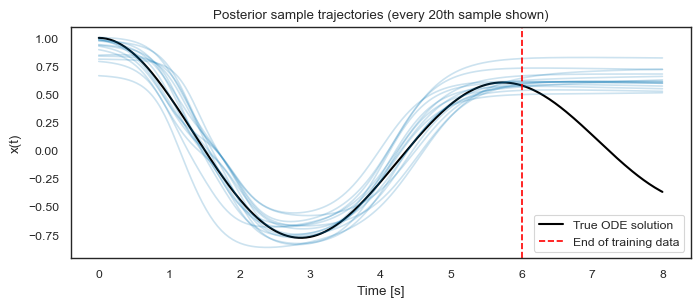

In [38]:
fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(t_eval.squeeze().cpu(), true_eval.squeeze().cpu(), color='black', linewidth=1.5, label='True ODE solution')
for sample in preds[::20]:
    ax.plot(t_eval.squeeze().cpu(), sample.squeeze().cpu(), color='C0', alpha=0.2)
ax.axvline(6.0, color='red', linestyle='--', label='End of training data')
ax.set_xlabel('Time [s]')
ax.set_ylabel('x(t)')
ax.set_title('Posterior sample trajectories (every 20th sample shown)')
ax.legend()
plt.show()
